In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../Data/attributes/structured_component_dataset_v1_clustered.csv")

print("Shape:", df.shape)
df.head()

Shape: (155, 27)


,image,component_id,class_id,component,confidence,x1,y1,x2,y2,width,...,normalized_width,normalized_height,brightness,contrast,min_intensity,max_intensity,detected_text,has_text,text_count,cluster
0,10002.png,0,2,CheckedTextView,0.502286,0.821686,82.077820,84.756989,284.991638,83.935303,...,0.058288,0.079263,179.031471,44.581621,50,255,NaN,False,0,0
1,10010.png,0,2,CheckedTextView,0.630227,0.432907,83.921669,83.684662,280.505280,83.251755,...,0.057814,0.076790,158.619350,33.390921,146,255,NaN,False,0,0
2,10010.png,1,2,CheckedTextView,0.427453,23.193726,80.703644,1363.871338,285.599701,1340.677612,...,0.931026,0.080038,186.758748,39.678008,146,255,NaN,False,0,1
3,10010.png,2,3,EditText,0.278310,0.000000,80.900490,82.139648,278.541290,82.139648,...,0.057041,0.077203,159.714400,35.140015,146,255,NaN,False,0,0
4,10031.png,0,2,CheckedTextView,0.597760,1.192478,86.552521,83.562469,278.167755,82.369991,...,0.057201,0.074850,89.039634,28.920227,84,255,NaN,False,0,0


In [3]:
print("Components:")
print(df["component"].value_counts())

print("\nClusters:")
print(df["cluster"].value_counts().sort_index())

Components:
component
CheckedTextView    71
Button             41
EditText           38
CheckBox            5
Name: count, dtype: int64

Clusters:
cluster
0    128
1     18
2      9
Name: count, dtype: int64


In [4]:
image_components = df.groupby("image")["component"].apply(list)

image_components.head()

image
10002.png                               [CheckedTextView]
10010.png    [CheckedTextView, CheckedTextView, EditText]
10031.png                               [CheckedTextView]
10042.png                               [CheckedTextView]
10050.png                              [Button, EditText]
Name: component, dtype: object

In [5]:
components = sorted(df["component"].unique())

cooccurrence = pd.DataFrame(0, index=components, columns=components)

for component_list in image_components:
    unique_components = set(component_list)

    for c1 in unique_components:
        for c2 in unique_components:
            cooccurrence.loc[c1, c2] += 1

cooccurrence

,Button,CheckBox,CheckedTextView,EditText
Button,41,5,18,37
CheckBox,5,5,3,5
CheckedTextView,18,3,47,16
EditText,37,5,16,38


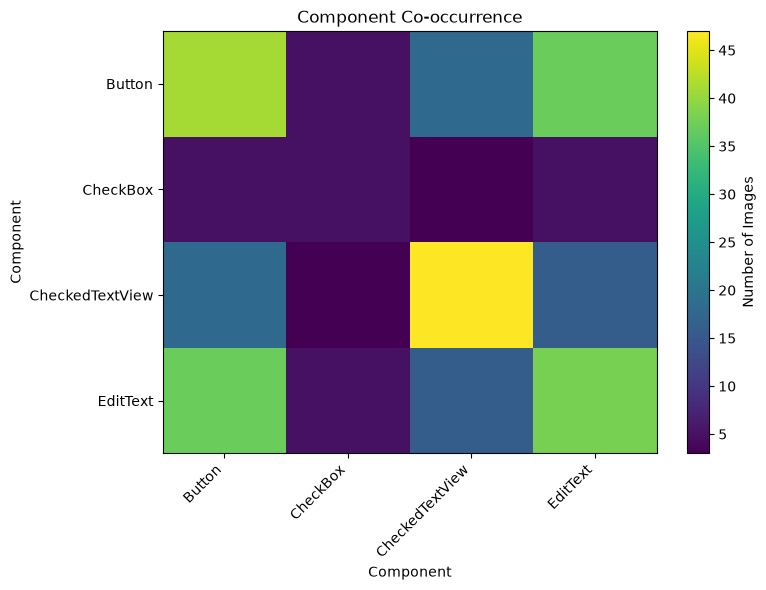

In [6]:
plt.figure(figsize=(8, 6))

plt.imshow(cooccurrence.values, aspect="auto")

plt.xticks(range(len(components)), components, rotation=45, ha="right")

plt.yticks(range(len(components)), components)

plt.xlabel("Component")
plt.ylabel("Component")
plt.title("Component Co-occurrence")

plt.colorbar(label="Number of Images")

plt.tight_layout()
plt.show()

In [7]:
relationships = []

for i, c1 in enumerate(components):
    for j, c2 in enumerate(components):

        if i < j:
            count = cooccurrence.loc[c1, c2]

            relationships.append(
                {"component_1": c1, "component_2": c2, "cooccurrence": count}
            )

relationship_df = pd.DataFrame(relationships)

relationship_df = relationship_df.sort_values("cooccurrence", ascending=False)

relationship_df.head(10)

,component_1,component_2,cooccurrence
2,Button,EditText,37
1,Button,CheckedTextView,18
5,CheckedTextView,EditText,16
0,Button,CheckBox,5
4,CheckBox,EditText,5
3,CheckBox,CheckedTextView,3


In [8]:
spatial_relationships = []

for image, group in df.groupby("image"):

    components_in_image = group.to_dict("records")

    for i in range(len(components_in_image)):

        for j in range(i + 1, len(components_in_image)):

            a = components_in_image[i]
            b = components_in_image[j]

            dx = b["center_x"] - a["center_x"]
            dy = b["center_y"] - a["center_y"]

            if abs(dx) > abs(dy):
                if dx > 0:
                    relation = "right_of"
                else:
                    relation = "left_of"
            else:
                if dy > 0:
                    relation = "below"
                else:
                    relation = "above"

            spatial_relationships.append(
                {
                    "image": image,
                    "component_1": a["component"],
                    "component_2": b["component"],
                    "cluster_1": a["cluster"],
                    "cluster_2": b["cluster"],
                    "relation": relation,
                    "dx": dx,
                    "dy": dy,
                }
            )

spatial_df = pd.DataFrame(spatial_relationships)

print("Spatial relationships:", len(spatial_df))
spatial_df.head()

Spatial relationships: 120


,image,component_1,component_2,cluster_1,cluster_2,relation,dx,dy
0,10010.png,CheckedTextView,CheckedTextView,0,1,right_of,651.473747,0.938198
1,10010.png,CheckedTextView,EditText,0,0,above,-0.988960,-2.492584
2,10010.png,CheckedTextView,EditText,1,0,left_of,-652.462708,-3.430782
3,10050.png,Button,EditText,0,0,above,-3.342873,-3.953064
4,10051.png,CheckedTextView,CheckedTextView,0,0,right_of,37.423082,1.360455


In [9]:
spatial_summary = (
    spatial_df.groupby(["component_1", "component_2", "relation"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

spatial_summary.head(20)

,component_1,component_2,relation,count
2,Button,EditText,above,33
1,Button,CheckedTextView,right_of,19
11,CheckedTextView,CheckedTextView,right_of,15
10,CheckedTextView,CheckedTextView,left_of,12
15,EditText,CheckedTextView,right_of,10
13,CheckedTextView,EditText,left_of,9
0,Button,CheckBox,right_of,5
14,EditText,CheckBox,right_of,5
4,Button,EditText,left_of,3
5,CheckBox,CheckedTextView,left_of,2


In [10]:
cluster_relationships = df.groupby("image")["cluster"].apply(lambda x: list(set(x)))

cluster_relationships.head()

image
10002.png       [0]
10010.png    [0, 1]
10031.png       [0]
10042.png       [0]
10050.png       [0]
Name: cluster, dtype: object

In [11]:
cluster_pairs = []

for clusters in cluster_relationships:

    for i in range(len(clusters)):
        for j in range(i + 1, len(clusters)):

            cluster_pairs.append({"cluster_1": clusters[i], "cluster_2": clusters[j]})

cluster_pair_df = pd.DataFrame(cluster_pairs)

cluster_pair_summary = cluster_pair_df.value_counts().reset_index(name="count")

cluster_pair_summary

,cluster_1,cluster_2,count
0,0,1,14
1,1,2,1


In [12]:
pattern_records = []

for _, row in spatial_summary.iterrows():

    pattern_records.append(
        {
            "type": "spatial_relationship",
            "component_1": row["component_1"],
            "component_2": row["component_2"],
            "relationship": row["relation"],
            "frequency": row["count"],
        }
    )

patterns_df = pd.DataFrame(pattern_records)

patterns_df.head()

,type,component_1,component_2,relationship,frequency
0,spatial_relationship,Button,EditText,above,33
1,spatial_relationship,Button,CheckedTextView,right_of,19
2,spatial_relationship,CheckedTextView,CheckedTextView,right_of,15
3,spatial_relationship,CheckedTextView,CheckedTextView,left_of,12
4,spatial_relationship,EditText,CheckedTextView,right_of,10


In [13]:
import os

os.makedirs("../Data/patterns", exist_ok=True)

In [14]:
patterns_df.to_csv("../Data/patterns/component_spatial_patterns.csv", index=False)

In [15]:
relationship_df.to_csv("../Data/patterns/component_cooccurrence.csv", index=False)

In [16]:
spatial_df.to_csv("../Data/patterns/spatial_relationships.csv", index=False)